## Airscope tube test dataset Visualization 

We'll visualize:
- Dataset structure and statistics
- PCA preprocessing results
- Data loader test

---

In [4]:
import os.path
import pickle
import re
import random
from datetime import datetime
from tqdm import tqdm
from functools import partial
from collections import OrderedDict, Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from dataset import CalciumDataset, CalciumDataset_two_stream
from dataset_augment import CalciumDataset_two_stream_pair_pca

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [11]:
# Configuration
data_dir = r"D:\BBNC\PICO\code\PICO_figure_plot\tube_test\data"  # Update this path
input_dim = 128  # PCA dimension
seq_length = 196

print("Configuration set!")
print(f"PCA dimensions: {input_dim}")
print(f"Sequence length: {seq_length}")

# Load data dictionaries
print("Loading data files...")

data_paths = [os.path.join(data_dir, tmp) for tmp in os.listdir(data_dir)]
pattern = re.compile(r'm(\d+)-m(\d+)')
data_dict_list = []

for data_path in data_paths:
    if data_path.endswith(".pkl"):
        with open(data_path, "rb") as f:
            data_dict = pickle.load(f)
            data_dict_list.append(data_dict)
        print(f"✓ Loaded: {os.path.basename(data_path)}")

        for key, value in data_dict.items():
            
            if pattern.match(key) and isinstance(value, dict):
                print(f"     - {key}: dict (matched pattern, nested structure)")
                for sub_key, sub_val in value.items():

                    if sub_key.startswith("trial") and isinstance(sub_val, dict):
                        print(f"         • {sub_key}: dict (trial-level structure)")
                        for inner_key, inner_val in sub_val.items():
                            if hasattr(inner_val, "shape"):
                                print(f"             · {inner_key}: {type(inner_val).__name__}, shape={inner_val.shape}")
                            elif isinstance(inner_val, (list, tuple)):
                                length = len(inner_val)
                                first_type = type(inner_val[0]).__name__ if length > 0 else "empty"
                                print(f"             · {inner_key}: {type(inner_val).__name__}, len={length}, first_elem={first_type}")
                            else:
                                print(f"             · {inner_key}: {type(inner_val).__name__}, value={inner_val}")
                    else:
                        if hasattr(sub_val, "shape"):
                            print(f"         • {sub_key}: {type(sub_val).__name__}, shape={sub_val.shape}")
                        elif isinstance(sub_val, (list, tuple)):
                            length = len(sub_val)
                            first_type = type(sub_val[0]).__name__ if length > 0 else "empty"
                            print(f"         • {sub_key}: {type(sub_val).__name__}, len={length}, first_elem={first_type}")
                        else:
                            print(f"         • {sub_key}: {type(sub_val).__name__}, value={sub_val}")

            else:
                if hasattr(value, "shape"):
                    print(f"     - {key}: {type(value).__name__}, shape={value.shape}")
                elif isinstance(value, (list, tuple)):
                    length = len(value)
                    first_type = type(value[0]).__name__ if length > 0 else "empty"
                    print(f"     - {key}: {type(value).__name__}, len={length}, first_elem={first_type}")
                else:
                    print(f"     - {key}: {type(value).__name__}, value={value}")

        print("-" * 60)

print(f"\nSuccessfully loaded {len(data_dict_list)} data files!")

# Create training dataset with full augmentation
print("Creating training dataset...")

train_dataset = CalciumDataset_two_stream_pair_pca(
    data_dict_list,
    seq_length=seq_length,
    pca_dim=input_dim,
    save_path="cache/train_data_integrated_pca_viz.pkl",
    training=True,
    # Augmentation parameters
    random_crop=True,
    channel_shuffle_prob=0.2,
    channel_shuffle_ratio=0.1,
    channel_dropout_prob=0.2,
    channel_dropout_ratio=0.1,
    time_mask_prob=0.2,
    time_mask_ratio=0.1
)

print(f"\n✓ Training dataset created successfully!")
print(f"   Total trials: {len(train_dataset)}")
print(f"   PCA dimensions: {input_dim}")
print(f"   Target sequence length: {seq_length}")

Configuration set!
PCA dimensions: 128
Sequence length: 196
Loading data files...
✓ Loaded: 0620_cage3.pkl
     - id_to_rank: dict, value={1: 'rank1', 2: 'rank4', 3: 'rank3', 4: 'rank2'}
     - cage_id: int, value=3
     - m1-m2: dict (matched pattern, nested structure)
         • neuron_center_1: ndarray, shape=(2847, 2)
         • neuron_name_1: list, len=2847, first_elem=str_
         • neuron_center_2: ndarray, shape=(4120, 2)
         • neuron_name_2: list, len=4120, first_elem=str_
         • start_frame: int64, shape=()
         • end_frame: int64, shape=()
         • calcium_whole_1: ndarray, shape=(2847, 1269)
         • calcium_whole_2: ndarray, shape=(4120, 1269)
         • trial_1: dict (trial-level structure)
             · winner: str, value=mouse1
             · time_start_end: ndarray, shape=(2, 1)
             · behavior_1: ndarray, shape=(182,)
             · calcium_1: ndarray, shape=(2847, 182)
             · behavior_2: ndarray, shape=(182,)
             · calcium_

## Data statisics

Generating comprehensive dataset visualization...
Dataset Summary:
    
Total Trials: 86
PCA Dimensions: 128
Target Seq Length: 196

Trial Length Stats:
Mean: 162.2
Std: 103.6

Label Balance:
Mouse 1 Wins: 44 (51.2%)
Mouse 2 Wins: 42 (48.8%)




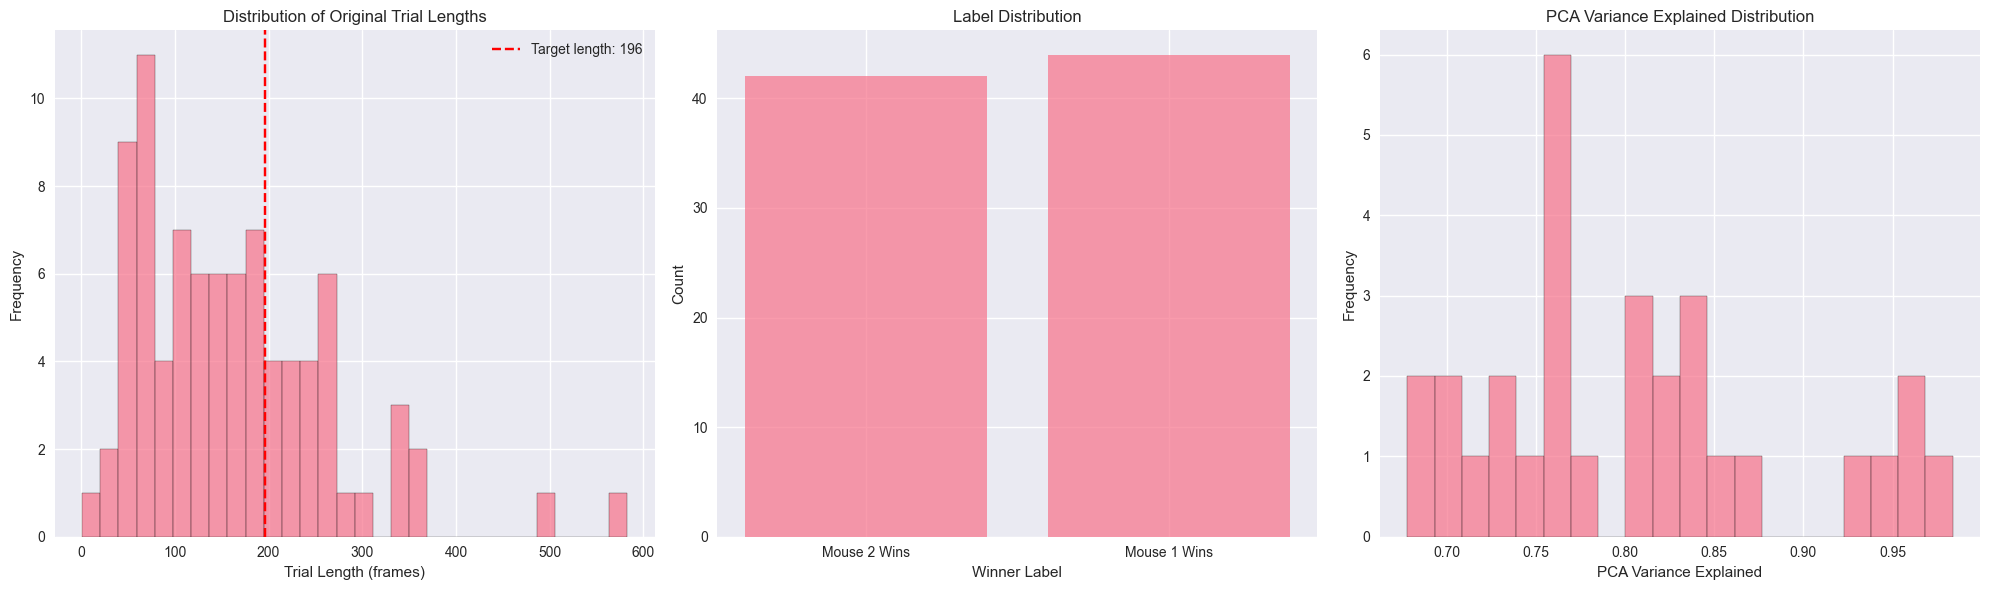

In [15]:
def visualize_dataset(dataset):
    """Create comprehensive visualizations of the dataset"""
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 6))
    
    # 1. Trial length distribution
    plt.subplot(1, 3, 1)
    plt.hist(dataset.trial_lengths, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(dataset.seq_length, color='red', linestyle='--', 
                label=f'Target length: {dataset.seq_length}')
    plt.xlabel('Trial Length (frames)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Original Trial Lengths')
    plt.legend()
    
    # 2. Label distribution
    plt.subplot(1, 3, 2)
    label_counts = Counter(dataset.win_labels)
    plt.bar(label_counts.keys(), label_counts.values(), alpha=0.7)
    plt.xlabel('Winner Label')
    plt.ylabel('Count')
    plt.title('Label Distribution')
    plt.xticks([0, 1], ['Mouse 2 Wins', 'Mouse 1 Wins'])
    
    # 3. PCA variance explained
    if dataset.pca_stats:
        plt.subplot(1, 3, 3)
        var_explained = [stat['mouse1_var_explained'] for stat in dataset.pca_stats] + \
                       [stat['mouse2_var_explained'] for stat in dataset.pca_stats]
        plt.hist(var_explained, bins=20, alpha=0.7, edgecolor='black')
        plt.xlabel('PCA Variance Explained')
        plt.ylabel('Frequency')
        plt.title('PCA Variance Explained Distribution')
    
    # Calculate summary statistics
    stats_text = f"""Dataset Summary:
    
Total Trials: {len(dataset)}
PCA Dimensions: {dataset.pca_dim}
Target Seq Length: {dataset.seq_length}

Trial Length Stats:
Mean: {np.mean(dataset.trial_lengths):.1f}
Std: {np.std(dataset.trial_lengths):.1f}

Label Balance:
Mouse 1 Wins: {sum(dataset.win_labels)} ({100*sum(dataset.win_labels)/len(dataset.win_labels):.1f}%)
Mouse 2 Wins: {len(dataset.win_labels)-sum(dataset.win_labels)} ({100*(len(dataset.win_labels)-sum(dataset.win_labels))/len(dataset.win_labels):.1f}%)

"""
    
    print(stats_text)
    
    plt.tight_layout()
    plt.show()

print("Generating comprehensive dataset visualization...")
visualize_dataset(train_dataset)

### PCA Sequence Visualization

Generating detailed sequence visualizations...


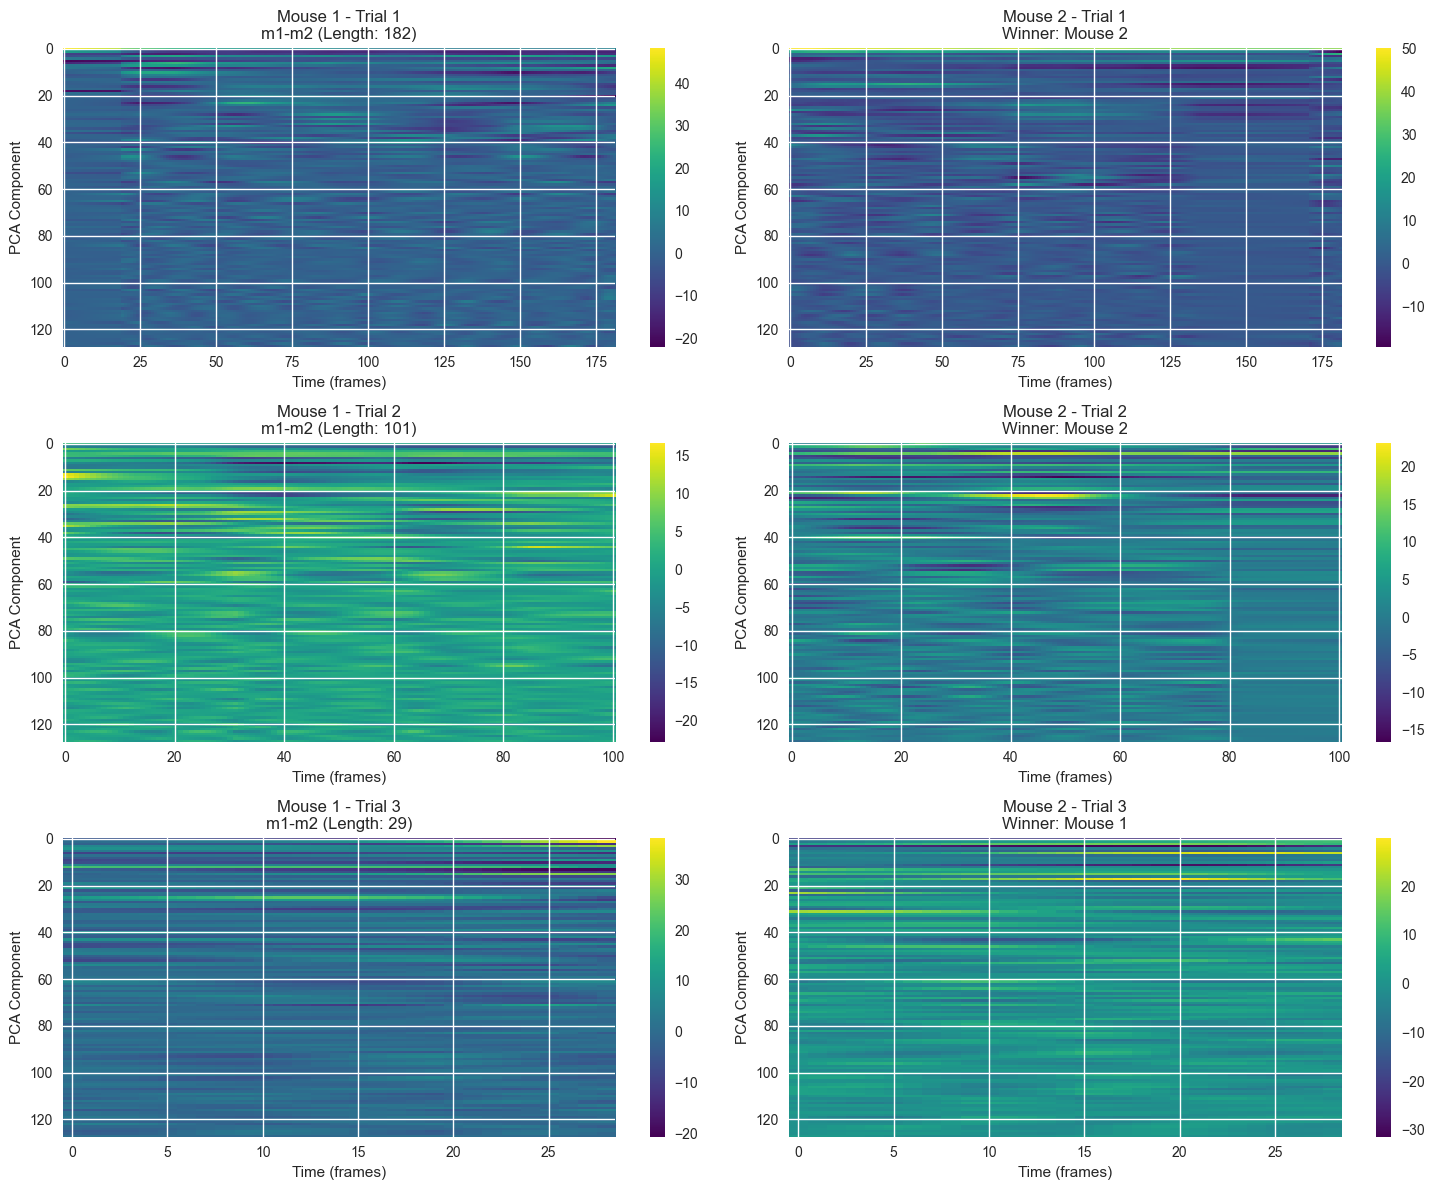

In [ ]:
### Detailed Sequence Visualization

def plot_sample_sequences(dataset, n_samples=3):
    """Plot detailed view of sample sequences"""
    
    sample_data = dataset.get_sample_data(n_samples=n_samples)
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(15, 4*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, sample in enumerate(sample_data):
        mouse1_data = sample['mouse1_data']
        mouse2_data = sample['mouse2_data']
        
        # Plot mouse 1 data
        ax1 = axes[i, 0]
        im1 = ax1.imshow(mouse1_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
        ax1.set_title(f'Mouse 1 - Trial {i+1}\n{sample["mouse_pair"]} (Length: {sample["trial_length"]})')
        ax1.set_xlabel('Time (frames)')
        ax1.set_ylabel('PCA Component')
        plt.colorbar(im1, ax=ax1)
        
        # Plot mouse 2 data
        ax2 = axes[i, 1]
        im2 = ax2.imshow(mouse2_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
        ax2.set_title(f'Mouse 2 - Trial {i+1}\nWinner: Mouse {sample["label"]+1}')
        ax2.set_xlabel('Time (frames)')
        ax2.set_ylabel('PCA Component')
        plt.colorbar(im2, ax=ax2)
    
    plt.tight_layout()
    plt.show()

print("Sequence visualization function defined!")

print("Generating detailed sequence visualizations...")
plot_sample_sequences(train_dataset, n_samples=3)

### PCA Preprocessing Analysis

PCA analysis function defined!
Analyzing PCA preprocessing results...
=== PCA Analysis Results ===

Variance Explained Summary:
Mouse 1 - Mean: 0.7931, Std: 0.0772
Mouse 2 - Mean: 0.8184, Std: 0.0933

Neuron Count Summary:
Mouse 1 - Mean: 3184.7
Mouse 2 - Mean: 3459.7


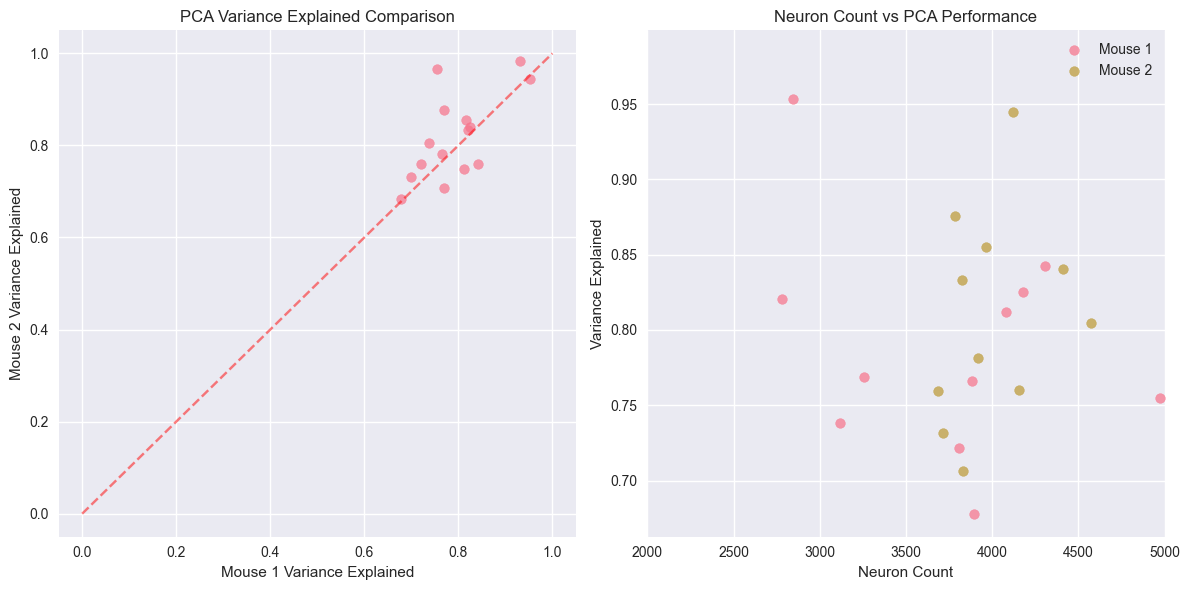

In [19]:
### PCA Analysis Function
def analyze_pca_results(dataset):
    """Detailed analysis of PCA preprocessing results"""
    
    if not dataset.pca_stats:
        print("No PCA statistics available!")
        return
    
    # Convert to DataFrame for easier analysis
    pca_df = pd.DataFrame(dataset.pca_stats)
    
    print("=== PCA Analysis Results ===\n")
    
    # Summary statistics
    print("Variance Explained Summary:")
    print(f"Mouse 1 - Mean: {pca_df['mouse1_var_explained'].mean():.4f}, Std: {pca_df['mouse1_var_explained'].std():.4f}")
    print(f"Mouse 2 - Mean: {pca_df['mouse2_var_explained'].mean():.4f}, Std: {pca_df['mouse2_var_explained'].std():.4f}")
    
    print(f"\nNeuron Count Summary:")
    print(f"Mouse 1 - Mean: {pca_df['mouse1_neurons'].mean():.1f}")
    print(f"Mouse 2 - Mean: {pca_df['mouse2_neurons'].mean():.1f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Variance explained comparison
    axes[0].scatter(pca_df['mouse1_var_explained'], pca_df['mouse2_var_explained'], alpha=0.7)
    axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.5)
    axes[0].set_xlabel('Mouse 1 Variance Explained')
    axes[0].set_ylabel('Mouse 2 Variance Explained')
    axes[0].set_title('PCA Variance Explained Comparison')

    # Variance vs neuron count
    axes[1].scatter(pca_df['mouse1_neurons'], pca_df['mouse1_var_explained'], alpha=0.7, label='Mouse 1')
    axes[1].scatter(pca_df['mouse2_neurons'], pca_df['mouse2_var_explained'], alpha=0.7, label='Mouse 2')
    axes[1].set_xlabel('Neuron Count')
    axes[1].set_ylabel('Variance Explained')
    axes[1].set_title('Neuron Count vs PCA Performance')
    axes[1].legend()
    axes[1].set_xlim([2000, 5000])

    plt.tight_layout()
    plt.show()
    
    return pca_df

print("PCA analysis function defined!")

print("Analyzing PCA preprocessing results...")
pca_results = analyze_pca_results(train_dataset)


### Test dataloader

In [20]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

print("Analyzing first training batch...")

# Analyze first batch
for batch_idx, batch in enumerate(train_loader):
    mouse1_data, mouse2_data, mouse1_mask, mouse2_mask, labels = batch
    
    print(f"\nBatch {batch_idx + 1} Analysis:")
    print(f"  Batch size: {len(labels)}")
    print(f"  Mouse1 data shape: {mouse1_data.shape}")
    print(f"  Mouse2 data shape: {mouse2_data.shape}")
    print(f"  Mouse1 mask shape: {mouse1_mask.shape}")
    print(f"  Mouse2 mask shape: {mouse2_mask.shape}")
    print(f"  Labels shape: {labels.shape}")
    
    # Data statistics
    print(f"\nData Statistics:")
    print(f"  Mouse1 mask coverage: {mouse1_mask.float().mean():.3f}")
    print(f"  Mouse2 mask coverage: {mouse2_mask.float().mean():.3f}")
    
    # Label distribution
    label_counts = torch.bincount(labels)
    print(f"\nLabel Distribution in Batch:")
    print(f"  Mouse 2 wins (label 0): {label_counts[0] if len(label_counts) > 0 else 0}")
    print(f"  Mouse 1 wins (label 1): {label_counts[1] if len(label_counts) > 1 else 0}")
    
    break  # Only analyze first batch

Analyzing first training batch...

Batch 1 Analysis:
  Batch size: 32
  Mouse1 data shape: torch.Size([32, 196, 128])
  Mouse2 data shape: torch.Size([32, 196, 128])
  Mouse1 mask shape: torch.Size([32, 196])
  Mouse2 mask shape: torch.Size([32, 196])
  Labels shape: torch.Size([32])

Data Statistics:
  Mouse1 mask coverage: 0.729
  Mouse2 mask coverage: 0.729

Label Distribution in Batch:
  Mouse 2 wins (label 0): 12
  Mouse 1 wins (label 1): 20
